In [2]:
import numpy as np
import scipy as sp
from scipy.fft import fft, fftfreq, ifft
import matplotlib.pyplot as plt
from tqdm import trange

In [34]:
class BrunelNeuron():
    def __init__(self, w, refractory_period=2e-4):
        self.w = w # connection weights
        self.refractory_period = refractory_period # duration of the refractory period after spiking
        self.Vr = 0 # 10 resting potential value
        self.Vth = 10 # 20 spiking threshold
        self.tau = 20e-3 # Time constant of excitatory neurons, from Brunel
        self.reset()

    def reset(self):
        self.V = np.array([self.Vr])
        self.n_spikes = 0
        self.spikes = np.array([0])
        self.bRefractory = False # is not in refractory period

    def update_potential(self, x):
        if(self.bRefractory):
            self.V = np.append(self.V, self.Vth)
            self.spikes = np.append(self.spikes, 0)
            ref_duration = self.dt * (self.V.shape[0] - self.refractory_starting_time)
            if(ref_duration > self.refractory_period):
                self.V[-1] = self.Vr
                self.bRefractory = False
            return
        new_V = self.V[-1] + self.dt * (- self.V[-1] / self.tau + self.w @ x)
        self.V = np.append(self.V, new_V)
        if(new_V > self.Vth):
            self.V[-1] = self.Vth
            self.spikes = np.append(self.spikes, 1)
            self.n_spikes += 1
            self.bRefractory = True
            self.refractory_starting_time = self.V.shape[0]
        else:
            self.spikes = np.append(self.spikes, 0)


In [35]:
class BrunelModelA():
    def __init__(self, N, Next, g, J, Ce, D:int, vext):
        self.N = N
        self.N1 = int(0.8*N) # excitatory neurons
        self.N2 = int(0.2*N) # inhibitory neurons
        self.Je = J
        self.g = g
        self.Ji = -g * J
        self.Ce = Ce
        self.Ci = 0.25 * Ce
        self.D = D
        self.Next = Next
        self.vext = vext
        
        self.neurons = []
        for i in range(self.N):
            w = np.concatenate([np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.N1),
                                np.random.choice([0, self.Ji], p=[1-self.Ci/self.N2, self.Ci/self.N2], size = self.N2),
                                np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.Next)])
            self.neurons.append(BrunelNeuron(w))

    def retrieve_potential(self, idx):
        V = []
        for neuron in self.neurons:
            V.append(neuron.V[idx])
        return np.array(V)

    def retrieve_spikes(self, idx):
        spikes = []
        for neuron in self.neurons:
            if(np.abs(idx)>neuron.spikes.shape[0]):
                spikes.append(0)
            else:
                spikes.append(neuron.spikes[idx])
        return np.array(spikes)

    def compute_spike_count(self):
        self.spike_count=np.zeros(self.n_steps)
        for idx in range(self.n_steps):
            for neuron in self.neurons:
                self.spike_count[idx] += neuron.spikes[idx]
    
    def compute_step(self):
        network_spikes = self.retrieve_spikes(-1-self.D)
        external_spikes = np.random.choice([0, 1], p=[1 - self.dt * self.vext, self.dt * self.vext], size = self.Next)
        spikes = np.concatenate([network_spikes, external_spikes])
        for neuron in self.neurons:
            neuron.update_potential(spikes)

    def compute_activity(self, T, dt):
        n_steps = int(T//dt)
        self.t = T
        self.dt = dt
        self.n_steps = n_steps
        for neuron in self.neurons:
            neuron.reset()
            neuron.dt = dt
        for i in trange(n_steps):
            self.compute_step()

    def plot_raster(self):
        event = []
        for neuron in self.neurons:
            st = neuron.spikes
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

In [443]:
model = BrunelModelA(N = 1000, Next = 1200, g=6, J=4, Ce=100, D=2, vext=800)

In [444]:
model.compute_activity(1, 0.001)

100%|████████████████████████████████████████████████████████████████████████████████| 999/999 [00:10<00:00, 95.49it/s]


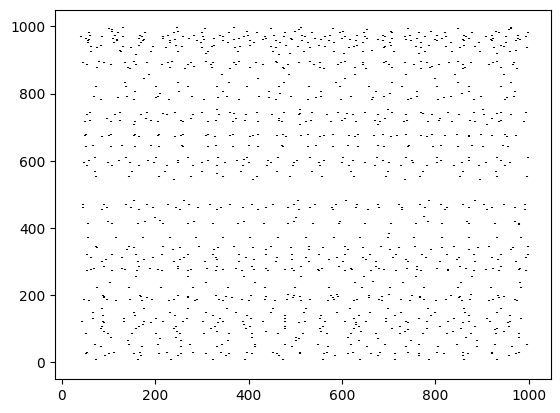

In [445]:
model.plot_raster()

In [411]:
class BrunelModelA_bis():
    def __init__(self, N, Next, g, J, Ce, D, vext):
        self.N = N
        self.N1 = int(0.8*N) # excitatory neurons
        self.N2 = int(0.2*N) # inhibitory neurons
        self.Next = Next # external input neurons
        
        self.Je = J # excitatory connection strength
        self.g = g
        self.Ji = - g * J # inhibitory connection strength
        
        self.Ce = Ce # nb of excitatory connections to a single neuron
        self.Ci = 0.25 * Ce # nb of inhibitory connections to a single neuron
        
        self.D = D # transmission delay of spikes
        self.vext = vext # external excitatory neurons firing rate
        self.refractory_period = 2e-3 # duration of the refractory period after spiking
        self.Vr = 10 # resting potential value in mV
        self.Vth = 20 # spiking threshold in mV
        self.te = 20e-3 # Time constant of excitatory neurons, from Brunel
        
        # Define the network-wide connectivity matrix W
        self.W = np.empty((self.N, self.N + self.Next))
        for i in range(self.N):
            self.W[i] = np.concatenate([np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.N1),
                                        np.random.choice([0, self.Ji], p=[1-self.Ci/self.N2, self.Ci/self.N2], size = self.N2),
                                        np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.Next)])
        # Reset potentials and spikes
        self.reset()
    
    def reset(self):
        self.V = np.full((1, self.N), self.Vr, dtype='float64') # all neurons are initiated at resting potential Vr
        self.spikes = np.zeros((1, self.N))
        self.spike_count = np.array(0)
        self.refractory_times = np.full(self.N, -1., dtype='float64') # array that holds the refractory periods as the elapsed time since last spike

    def compute_spike_count(self):
        self.spike_count = np.sum(self.spikes, axis = 1)
    
    def compute_step(self):
        # Internal spiking activity at time t - D
        delay = int(self.D//self.dt)
        if(delay + 1 > self.spikes.shape[0]):
            network_spikes = np.zeros(self.N)
        else:
            network_spikes = self.spikes[- 1 - delay]
        # External spiking excitation
        external_spikes = np.random.choice([0, 1], p=[1 - self.vext, self.vext], size = self.Next)
        # Total input
        spikes = np.concatenate([network_spikes, external_spikes])
        # Potential update (see Brunel, eq. 1)
        new_V = self.V[-1] + self.dt * (- self.V[-1] / self.te + np.matvec(self.W, spikes))
        # Neurons in refractory period remain unchanged
        new_V[self.refractory_times >= 0] = self.Vr # Reset to resting potential
        self.refractory_times[self.refractory_times >= 0] += self.dt # Update the time since last spike
        self.refractory_times[self.refractory_times > self.refractory_period] = -1 # Ready to spike
        # Compute the spikes
        new_spikes = np.where(new_V > self.Vth, 1, 0)
        # Update the new refractory neurons
        self.refractory_times[new_spikes == 1] = 0 # Start refractory period
        self.V = np.concatenate([self.V, [new_V]])
        self.spikes = np.concatenate([self.spikes, [new_spikes]])

    def compute_activity(self, T, dt):
        self.reset()
        n_steps = int(T//dt)
        self.T = T
        self.dt = dt
        self.n_steps = n_steps
        for i in trange(n_steps, desc="Computing potential dynamics step"):
            self.compute_step()
        self.compute_spike_count()

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

In [475]:
model_bis = BrunelModelA_bis(N = 1000, Next = 1000, g=0.4, J=4, Ce=400, D=2e-3, vext=0.5)

In [476]:
model_bis.compute_activity(1, 1e-3)

Computing potential dynamics step: 100%|████████████████████████████████████████████| 999/999 [00:01<00:00, 520.38it/s]


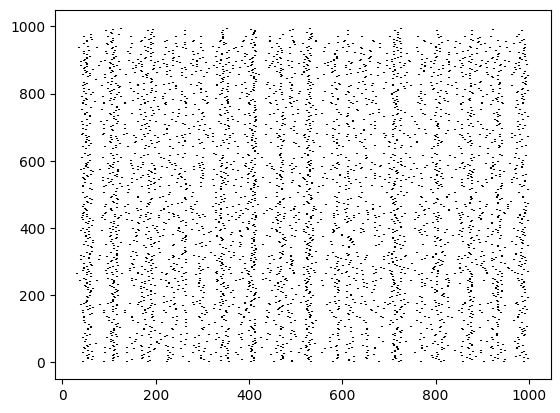

In [477]:
model_bis.plot_raster()

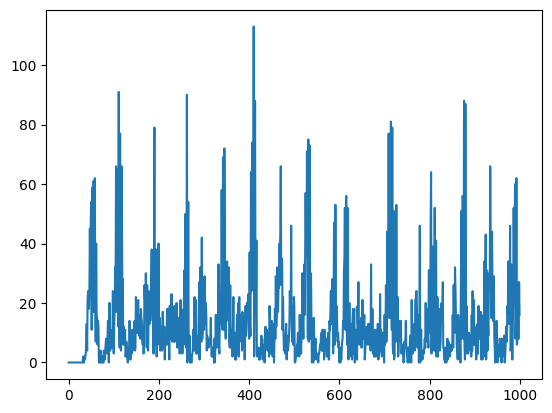

In [478]:
plt.plot(model_bis.spike_count)